In [9]:
!pip install torch torchvision matplotlib seaborn scikit-learn kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
import kagglehub
import os

print("Загрузка датасета EuroSAT (спутниковые снимки)...")
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print(f"Путь к датасету: {path}")
print("Содержимое папки:")
print(os.listdir(path))

# Проверяем возможные варианты пути
possible_paths = [
    os.path.join(path, "EuroSAT_RGB"),
    os.path.join(path, "archive", "EuroSAT_RGB"),
    os.path.join(path, "EuroSAT"),
    os.path.join(path, "2750"),
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    # Ищем любую папку с изображениями
    for root, dirs, files in os.walk(path):
        if "RGB" in root or "eurosat" in root.lower():
            for d in dirs:
                if d in ["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial", "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"]:
                    data_path = root
                    break
            if data_path:
                break

print(f"Найденный путь к данным: {data_path}")

if data_path is None:
    raise FileNotFoundError("Не удалось найти папку с данными EuroSAT")

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(root=data_path, transform=transform_train)
class_names = dataset.classes
print(f"Классы: {class_names}")
print(f"Всего изображений: {len(dataset)}")

Загрузка датасета EuroSAT (спутниковые снимки)...
Путь к датасету: /root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6
Содержимое папки:
['EuroSATallBands', 'EuroSAT']
Найденный путь к данным: /root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6/EuroSAT
Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Всего изображений: 27000


In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 18900, Val: 4050, Test: 4050


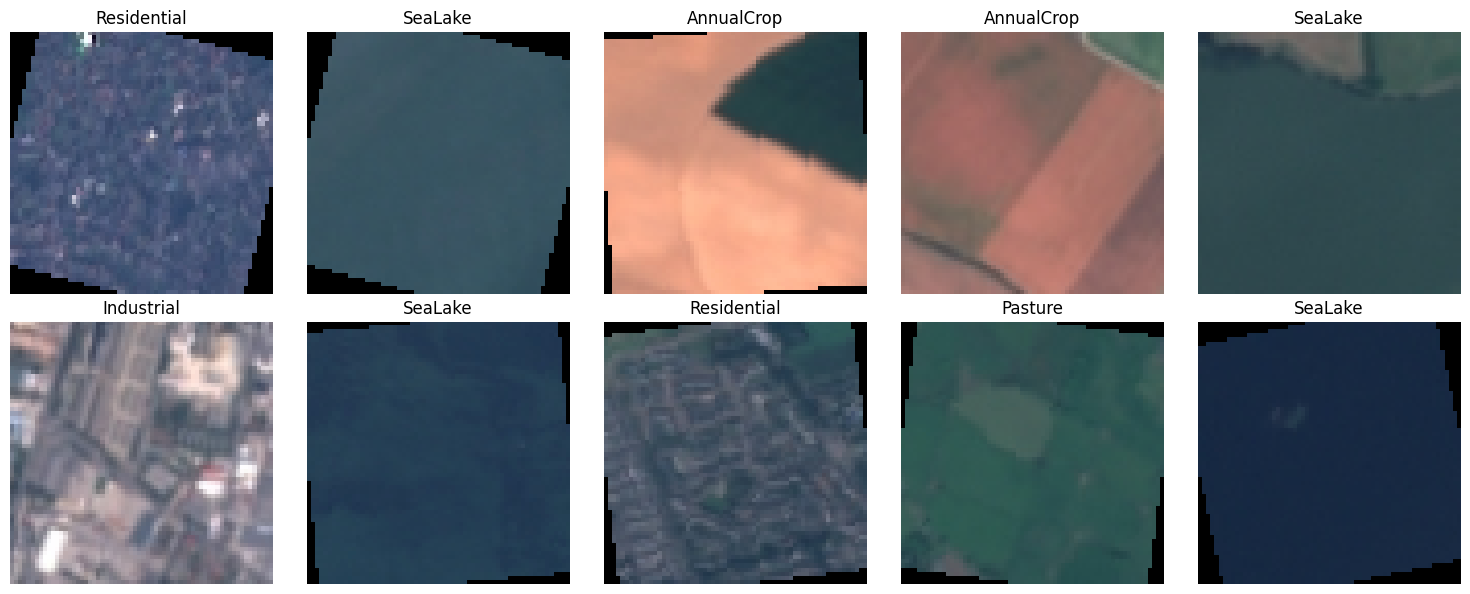

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, (img, label) in enumerate(train_dataset):
    if i >= 10:
        break
    img_np = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    axes[i//5, i%5].imshow(img_np)
    axes[i//5, i%5].set_title(class_names[label])
    axes[i//5, i%5].axis('off')

plt.tight_layout()
plt.show()

In [22]:
class SatelliteCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SatelliteCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SatelliteCNN(num_classes=len(class_names)).to(device)
print(model)

SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

In [11]:
num_epochs = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cnn_model.pth')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.2f}% - Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [5/15] - Train Acc: 91.91% - Val Acc: 93.28%
Epoch [10/15] - Train Acc: 93.03% - Val Acc: 93.93%
Epoch [15/15] - Train Acc: 93.47% - Val Acc: 95.14%

Best Validation Accuracy: 95.14%


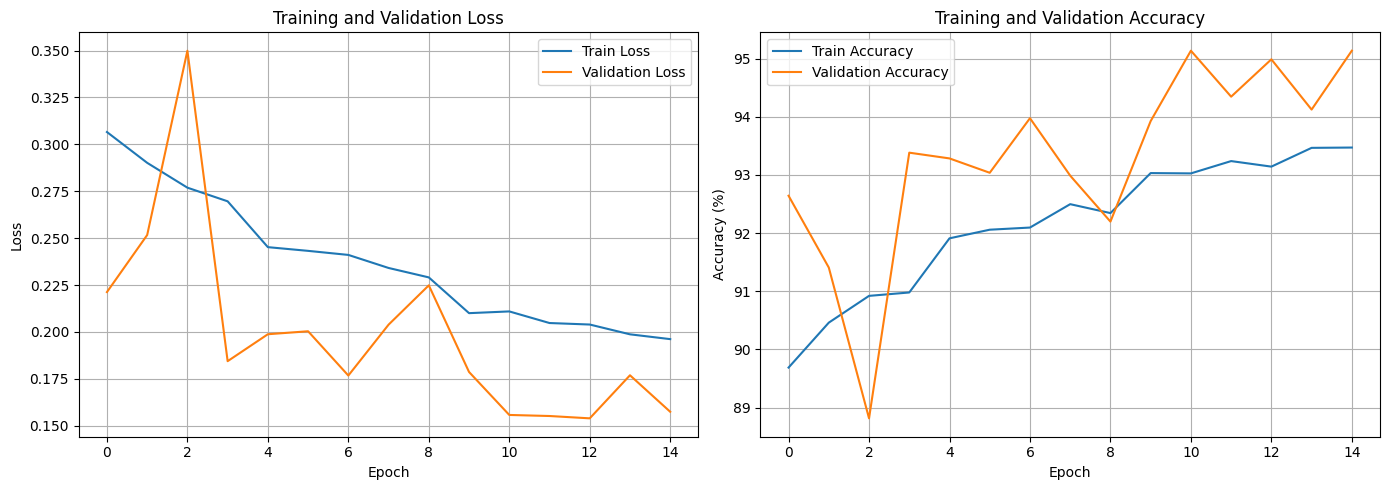

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
model.load_state_dict(torch.load('best_cnn_model.pth'))
test_loss, test_acc = validate(model, test_loader, criterion)
print(f"CNN Test Accuracy: {test_acc:.2f}%")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report (CNN):")
print(classification_report(all_labels, all_preds, target_names=class_names))

CNN Test Accuracy: 95.04%

Classification Report (CNN):
                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.94      0.93       447
              Forest       0.98      0.98      0.98       429
HerbaceousVegetation       0.90      0.96      0.93       448
             Highway       0.96      0.96      0.96       370
          Industrial       1.00      0.95      0.97       403
             Pasture       0.94      0.92      0.93       300
       PermanentCrop       0.95      0.90      0.92       356
         Residential       0.95      1.00      0.97       443
               River       0.95      0.91      0.93       370
             SeaLake       0.98      0.98      0.98       484

            accuracy                           0.95      4050
           macro avg       0.95      0.95      0.95      4050
        weighted avg       0.95      0.95      0.95      4050



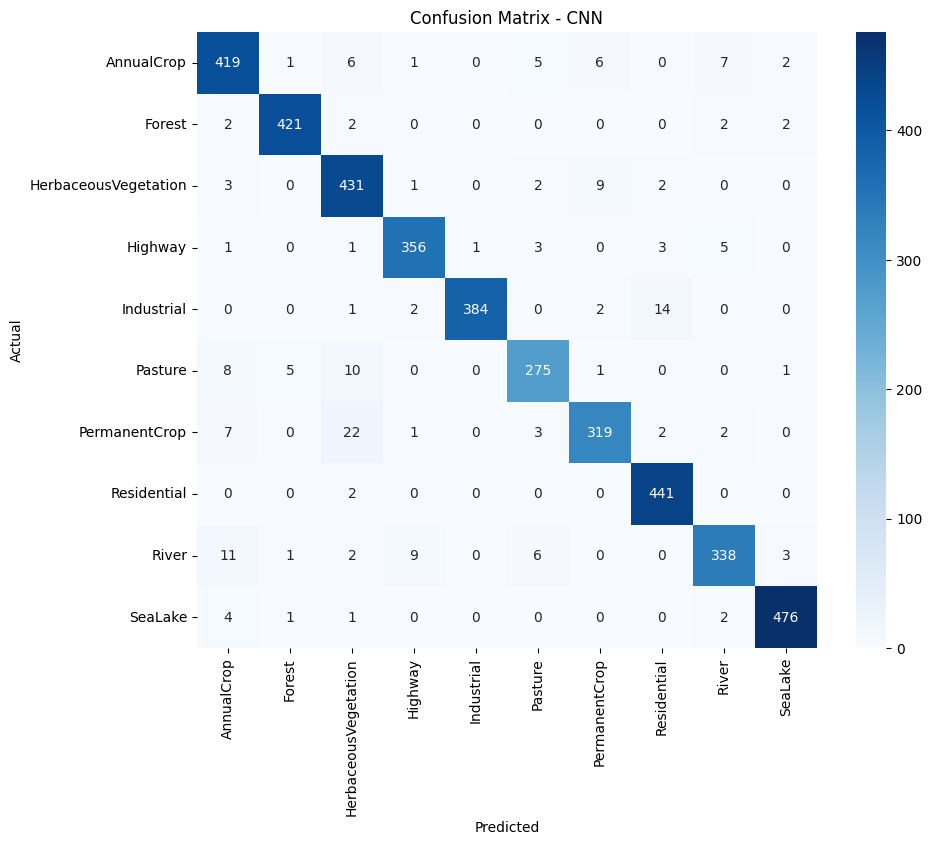

In [14]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN')
plt.show()

In [15]:
import torchvision.models as models

resnet = models.resnet18(pretrained=True)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, len(class_names))
resnet = resnet.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet.parameters(), lr=0.0005)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', patience=3, factor=0.5)

resnet_val_accs = []
best_resnet_acc = 0

print("Обучение ResNet18 (fine-tuning)...")
for epoch in range(15):
    train_loss, train_acc = train_epoch(resnet, train_loader, optimizer_resnet, criterion_resnet)
    val_loss, val_acc = validate(resnet, val_loader, criterion_resnet)
    resnet_val_accs.append(val_acc)
    scheduler_resnet.step(val_loss)

    if val_acc > best_resnet_acc:
        best_resnet_acc = val_acc
        torch.save(resnet.state_dict(), 'best_resnet_model.pth')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/15] - Train Acc: {train_acc:.2f}% - Val Acc: {val_acc:.2f}%")

print(f"\nBest ResNet18 Validation Accuracy: {best_resnet_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 277MB/s]


Обучение ResNet18 (fine-tuning)...
Epoch [5/15] - Train Acc: 94.50% - Val Acc: 93.21%
Epoch [10/15] - Train Acc: 97.60% - Val Acc: 96.86%
Epoch [15/15] - Train Acc: 98.55% - Val Acc: 96.86%

Best ResNet18 Validation Accuracy: 96.86%


In [16]:
resnet.load_state_dict(torch.load('best_resnet_model.pth'))
test_loss, test_acc = validate(resnet, test_loader, criterion_resnet)
print(f"ResNet18 Test Accuracy: {test_acc:.2f}%")

resnet.eval()
all_preds_resnet, all_labels_resnet = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet(images)
        _, predicted = outputs.max(1)
        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.numpy())

print("\nClassification Report (ResNet18):")
print(classification_report(all_labels_resnet, all_preds_resnet, target_names=class_names))

ResNet18 Test Accuracy: 96.89%

Classification Report (ResNet18):
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.94      0.96       447
              Forest       0.98      0.98      0.98       429
HerbaceousVegetation       0.96      0.95      0.95       448
             Highway       0.96      0.96      0.96       370
          Industrial       0.99      0.97      0.98       403
             Pasture       0.96      0.97      0.96       300
       PermanentCrop       0.90      0.96      0.93       356
         Residential       0.99      0.99      0.99       443
               River       0.96      0.97      0.96       370
             SeaLake       0.98      0.99      0.99       484

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050



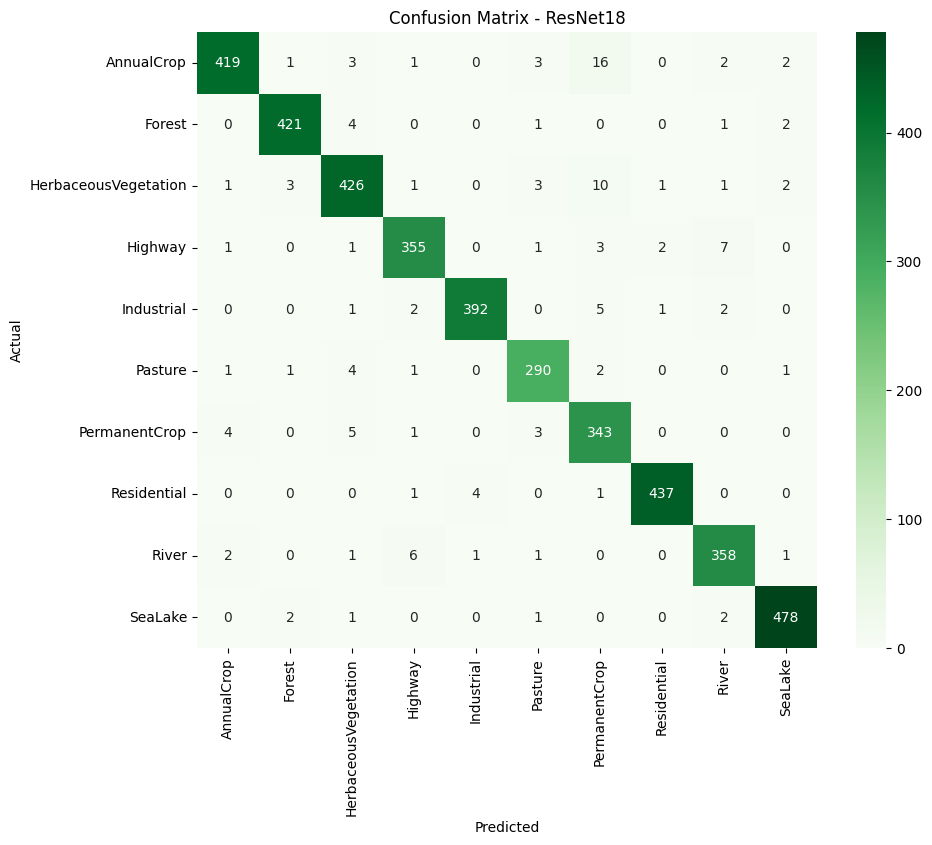

In [17]:
cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ResNet18')
plt.show()

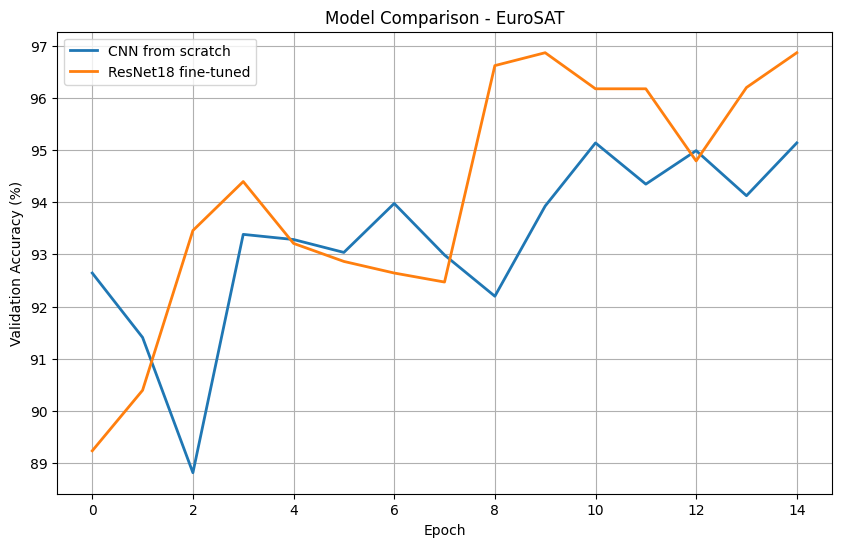

ИТОГОВОЕ СРАВНЕНИЕ
CNN from scratch - Best Val Acc: 95.14%
CNN from scratch - Test Acc: 96.89%
ResNet18 fine-tuned - Best Val Acc: 96.86%
ResNet18 fine-tuned - Test Acc: (блок 12)


In [19]:
plt.figure(figsize=(10, 6))
plt.plot(val_accs, label='CNN from scratch', linewidth=2)
plt.plot(resnet_val_accs, label='ResNet18 fine-tuned', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison - EuroSAT')
plt.legend()
plt.grid(True)
plt.show()

print("="*50)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("="*50)
print(f"CNN from scratch - Best Val Acc: {max(val_accs):.2f}%")
print(f"CNN from scratch - Test Acc: {test_acc:.2f}%")
print(f"ResNet18 fine-tuned - Best Val Acc: {max(resnet_val_accs):.2f}%")

try:
    print(f"ResNet18 fine-tuned - Test Acc: {test_acc_resnet:.2f}%")
except NameError:
    print("ResNet18 fine-tuned - Test Acc: (блок 12)")

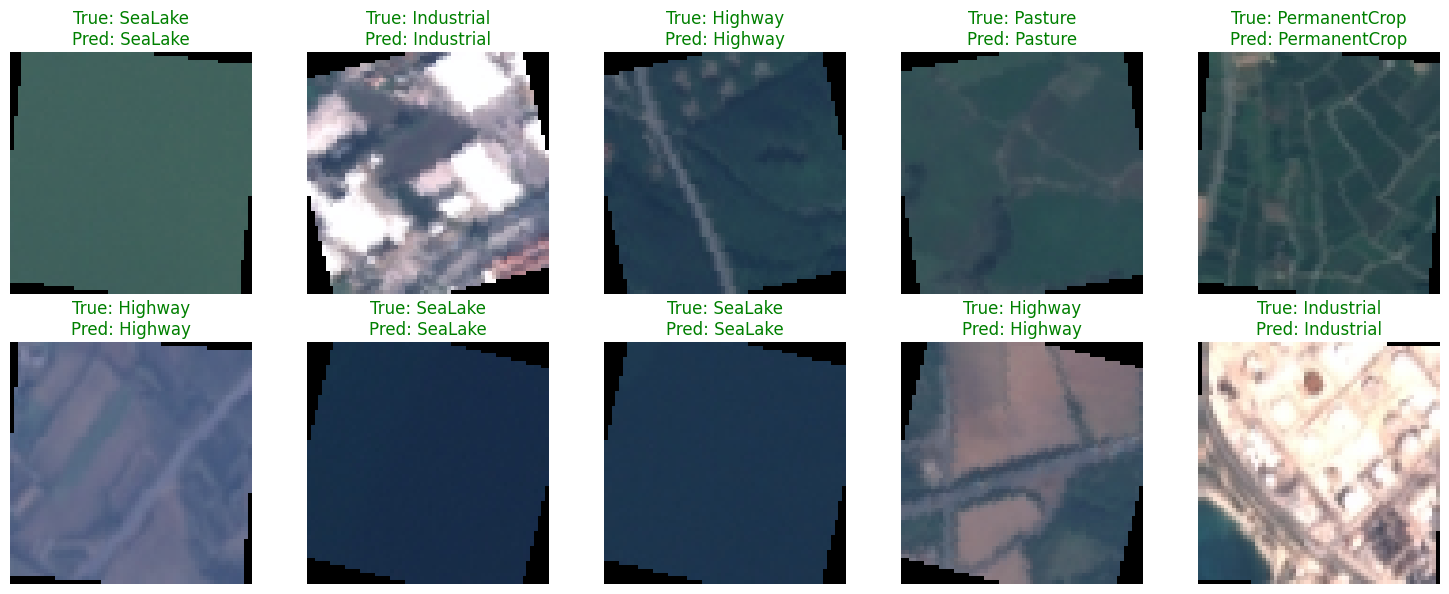

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    img, true_label = test_dataset[i]
    img_display = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    img_tensor = img.unsqueeze(0).to(device)
    with torch.no_grad():
        output = resnet(img_tensor)
        pred_label = output.argmax().item()

    color = 'green' if pred_label == true_label else 'red'
    axes[i].imshow(img_display)
    axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()